<a href="https://colab.research.google.com/github/karen-nakaoka/TelecomX_2/blob/main/TelecomX_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracão

In [2]:
import pandas as pd

telecomx_2 = pd.read_csv('telecomx_tratado.csv')

telecomx_2.head()

,Cliente_id,Evasão,Gênero,Idoso,Parceiro,Dependentes,Meses de contrato,Ass. de servico telefônico,Ass. de múltiplas linhas,Ass. de provedor internet,...,Ass. de tv a cabo,Ass. de streaming de filmes,Tipo de contrato,Prefere fatura online,Forma de pagamento,Gasto mensal,Gasto total,Gasto diário,Faixa_tempo_contrato,Faixa_gasto_mensal
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,Yes,No,One year,1,Mailed check,65.6,593.30,2.19,0-12 meses,40-70
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,2.00,0-12 meses,40-70
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.46,0-12 meses,70-100
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.27,13-24 meses,70-100
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.80,0-12 meses,70-100


In [3]:
telecomx_2.isnull().sum()

,0
Cliente_id,0
Evasão,0
Gênero,0
Idoso,0
Parceiro,0
Dependentes,0
Meses de contrato,0
Ass. de servico telefônico,0
Ass. de múltiplas linhas,0
Ass. de provedor internet,0


In [4]:
telecomx_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Cliente_id                       7043 non-null   object 
 1   Evasão                           7043 non-null   int64  
 2   Gênero                           7043 non-null   object 
 3   Idoso                            7043 non-null   int64  
 4   Parceiro                         7043 non-null   int64  
 5   Dependentes                      7043 non-null   int64  
 6   Meses de contrato                7043 non-null   int64  
 7   Ass. de servico telefônico       7043 non-null   int64  
 8   Ass. de múltiplas linhas         7043 non-null   object 
 9   Ass. de provedor internet        7043 non-null   object 
 10  Ass. de segurança online         7043 non-null   object 
 11  Ass. de backup online            7043 non-null   object 
 12  Ass. de proteção no 

In [5]:
telecomx_2.shape

(7043, 24)

# 🛠️ Preparação dos Dados

**Remoção de colunas irrelevantes**

In [6]:
telecomx_2.drop(columns=['Cliente_id'], inplace=True)

In [7]:
telecomx_2.drop(columns=['Faixa_gasto_mensal'], inplace=True)

In [8]:
telecomx_2.drop(columns=['Faixa_tempo_contrato'], inplace=True)

In [9]:
telecomx_2.drop(columns=['Gasto diário'], inplace=True)

In [10]:
telecomx_2.columns

Index(['Evasão', 'Gênero', 'Idoso', 'Parceiro', 'Dependentes',
       'Meses de contrato', 'Ass. de servico telefônico',
       'Ass. de múltiplas linhas', 'Ass. de provedor internet',
       'Ass. de segurança online', 'Ass. de backup online',
       'Ass. de proteção no dispositivo', 'Ass. de suporte técnico',
       'Ass. de tv a cabo', 'Ass. de streaming de filmes', 'Tipo de contrato',
       'Prefere fatura online', 'Forma de pagamento', 'Gasto mensal',
       'Gasto total'],
      dtype='object')

**Encoding**

In [11]:
X = telecomx_2.drop('Evasão', axis=1)
y = telecomx_2['Evasão']

In [12]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [13]:
X_encoded.head()

,Idoso,Parceiro,Dependentes,Meses de contrato,Ass. de servico telefônico,Prefere fatura online,Gasto mensal,Gasto total,Gênero_Male,Ass. de múltiplas linhas_No phone service,...,Ass. de suporte técnico_Yes,Ass. de tv a cabo_No internet service,Ass. de tv a cabo_Yes,Ass. de streaming de filmes_No internet service,Ass. de streaming de filmes_Yes,Tipo de contrato_One year,Tipo de contrato_Two year,Forma de pagamento_Credit card (automatic),Forma de pagamento_Electronic check,Forma de pagamento_Mailed check
0,0,1,1,9,1,1,65.6,593.30,False,False,...,True,False,True,False,False,True,False,False,False,True
1,0,0,0,9,1,0,59.9,542.40,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,0,0,4,1,1,73.9,280.85,True,False,...,False,False,False,False,False,False,False,False,True,False
3,1,1,0,13,1,1,98.0,1237.85,True,False,...,False,False,True,False,True,False,False,False,True,False
4,1,1,0,3,1,1,83.9,267.40,False,False,...,True,False,True,False,False,False,False,False,False,True


**Verificação da proporção de evasão**

In [14]:
proporcao_evasao = y.value_counts(normalize=True) * 100
proporcao_evasao

,proportion
Evasão,
0,73.463013
1,26.536987


**Padronização**

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#🎯 Correlação e Seleção de Variáveis

In [17]:
correlacao = X_encoded.copy()
correlacao['Evasão'] = y

correlacao_matrix = correlacao.corr()

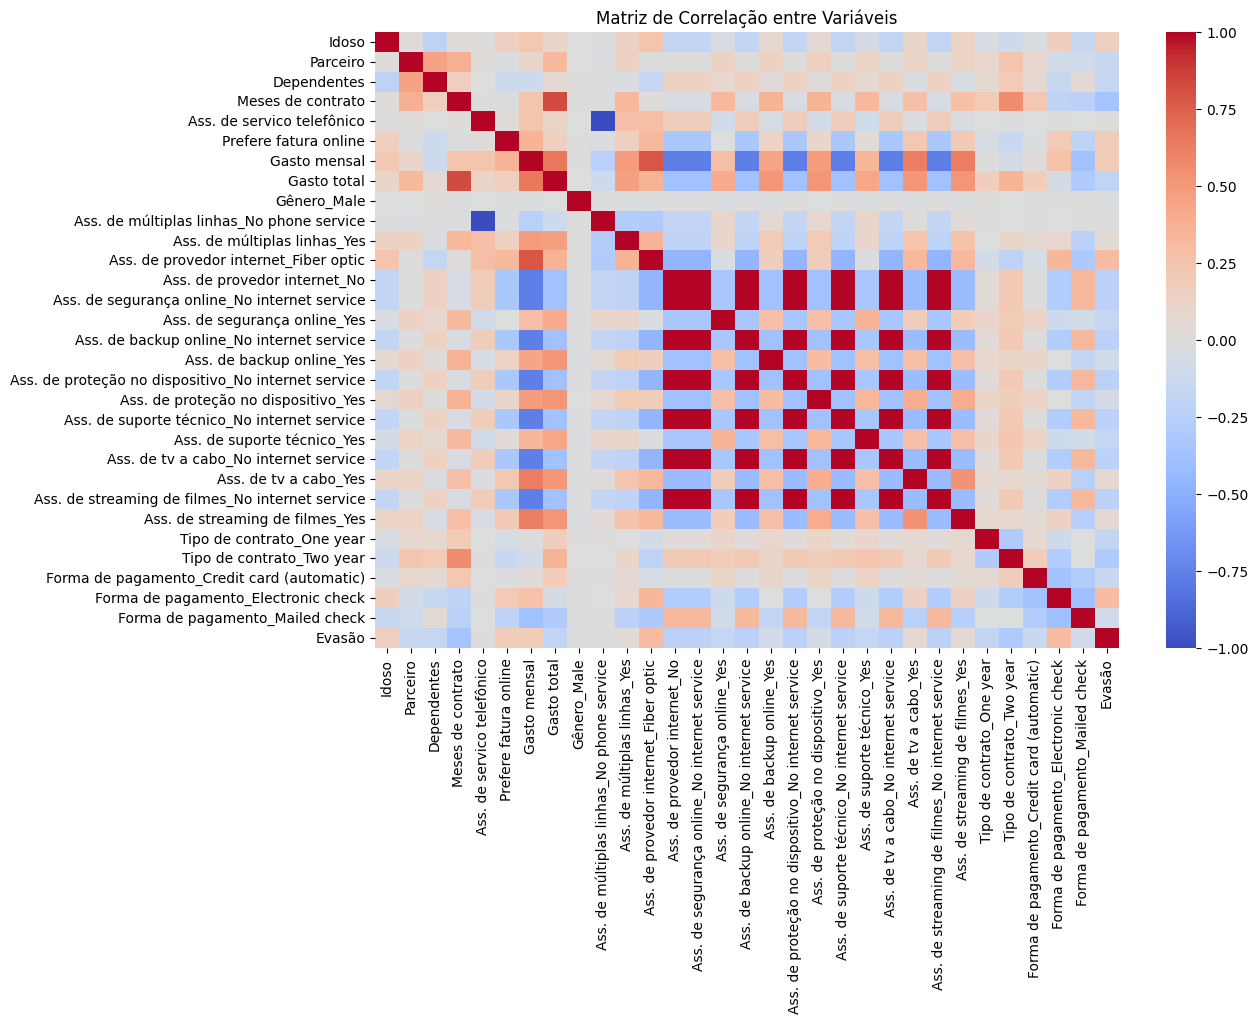

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    correlacao_matrix,
    cmap='coolwarm',
    annot=False
)

plt.title('Matriz de Correlação entre Variáveis')
plt.show()

In [19]:
correlacao_evasao = correlacao_matrix['Evasão'].sort_values(ascending=False)
correlacao_evasao

,Evasão
Evasão,1.000000
Ass. de provedor internet_Fiber optic,0.308020
Forma de pagamento_Electronic check,0.301919
Gasto mensal,0.193356
Prefere fatura online,0.191825
Idoso,0.150889
Ass. de tv a cabo_Yes,0.063228
Ass. de streaming de filmes_Yes,0.061382
Ass. de múltiplas linhas_Yes,0.040102
Ass. de servico telefônico,0.011942


**Tempo de contrato X Evasão**

/tmp/ipykernel_1734/3089727251.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


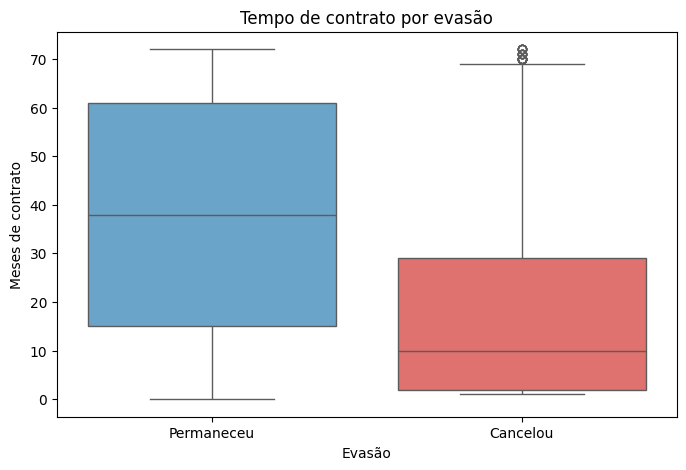

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=y,
    y=telecomx_2['Meses de contrato'],
    palette=['#5BA8D7','#F25F5C']
)

plt.title('Tempo de contrato por evasão')
plt.xlabel('Evasão')
plt.ylabel('Meses de contrato')

plt.xticks([0,1], ['Permaneceu','Cancelou'])

plt.show()

**Gasto total X Evasão**

/tmp/ipykernel_1734/421807956.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


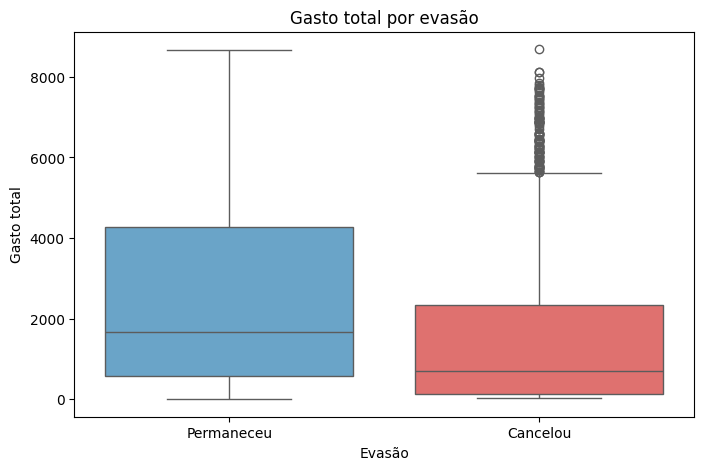

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=y,
    y=telecomx_2['Gasto total'],
    palette=['#5BA8D7','#F25F5C']
)

plt.title('Gasto total por evasão')
plt.xlabel('Evasão')
plt.ylabel('Gasto total')

plt.xticks([0,1], ['Permaneceu','Cancelou'])

plt.show()

#🤖 Modelagem Preditiva

**Separação de dados**

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (5634, 30)
Teste: (1409, 30)


**Criação de Modelos**

Nesta etapa foram criados dois modelos de classificação para prever a evasão de clientes. O primeiro modelo utilizado foi a Regressão Logística, amplamente aplicada em problemas de classificação binária por sua simplicidade e interpretabilidade. O segundo modelo escolhido foi o Random Forest, um algoritmo baseado em árvores de decisão que combina múltiplas árvores para capturar relações mais complexas entre as variáveis. A escolha desses dois modelos permite comparar diferentes abordagens de aprendizado e avaliar qual apresenta melhor desempenho na previsão da evasão.
A normalização dos dados pode ser importante para modelos sensíveis à escala, como a Regressão Logística. No entanto, modelos baseados em árvores, como Random Forest, não são sensíveis à escala das variáveis.

**Modelo 1 - Regressão logística**

In [24]:
from sklearn.linear_model import LogisticRegression

modelo_lr = LogisticRegression(max_iter=5000)

modelo_lr.fit(X_train, y_train)

y_pred_lr = modelo_lr.predict(X_test)

**Modelo 2 - Random Forest**

In [25]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(random_state=42)

modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)

**Avaliação dos modelos**

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [27]:
print("Acurácia:", accuracy_score(y_test, y_pred_lr))
print("Precisão:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1-score:", f1_score(y_test, y_pred_lr))

Acurácia: 0.7920511000709723
Precisão: 0.6310679611650486
Recall: 0.5213903743315508
F1-score: 0.5710102489019033


In [28]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
print("Matriz de confusão:")
print(cm_lr)

Matriz de confusão:
[[921 114]
 [179 195]]


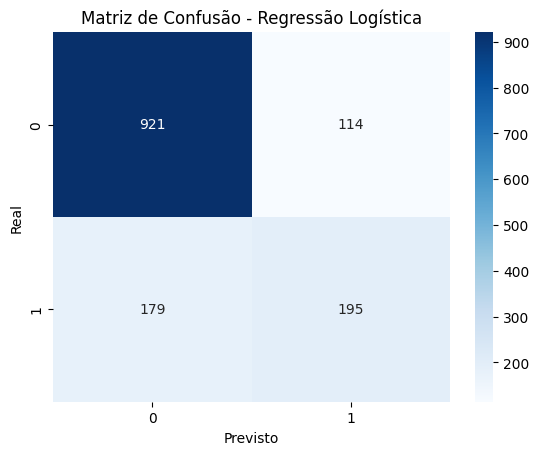

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusão - Regressão Logística")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

In [30]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



In [31]:
accuracy_score(y_test, y_pred_rf)

0.7835344215755855

**Comparação dos modelos**

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

resultados = pd.DataFrame({

    "Modelo": ["Regressão Logística", "Random Forest"],

    "Acurácia": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],

    "Precisão": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],

    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],

    "F1-score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ]
})

resultados

,Modelo,Acurácia,Precisão,Recall,F1-score
0,Regressão Logística,0.792051,0.631068,0.521390,0.57101
1,Random Forest,0.783534,0.624549,0.462567,0.53149


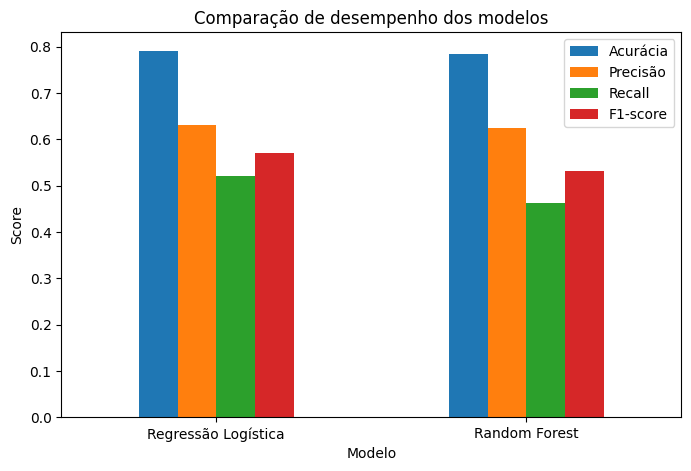

In [33]:
resultados.set_index("Modelo").plot(kind="bar", figsize=(8,5))

plt.title("Comparação de desempenho dos modelos")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

# Análise de importância de variáveis

**Regressão logística**

In [34]:
coeficientes = pd.DataFrame({
    "Variável": X_encoded.columns,
    "Coeficiente": modelo_lr.coef_[0]
})

coeficientes = coeficientes.sort_values(by="Coeficiente", ascending=False)

coeficientes.head(10)

,Variável,Coeficiente
11,Ass. de provedor internet_Fiber optic,0.621455
28,Forma de pagamento_Electronic check,0.403422
5,Prefere fatura online,0.367042
10,Ass. de múltiplas linhas_Yes,0.286626
9,Ass. de múltiplas linhas_No phone service,0.244358
0,Idoso,0.199852
22,Ass. de tv a cabo_Yes,0.188850
24,Ass. de streaming de filmes_Yes,0.081894
29,Forma de pagamento_Mailed check,0.024812
6,Gasto mensal,0.002973


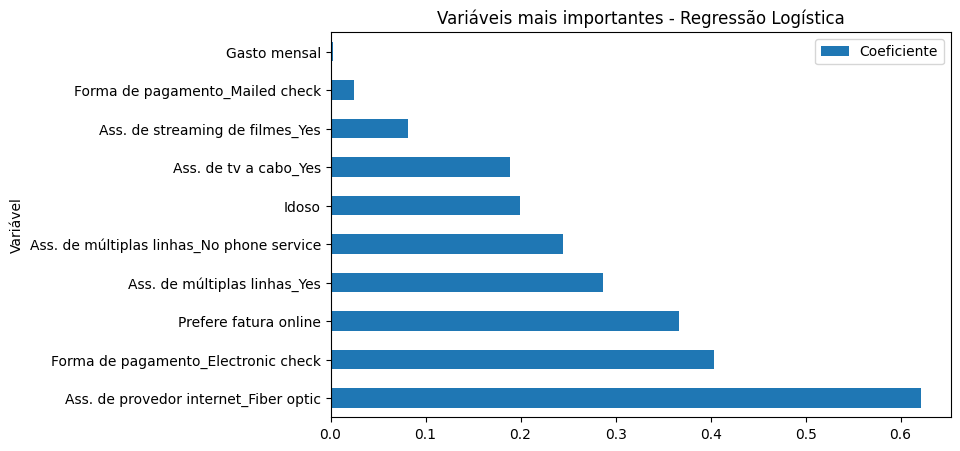

In [35]:
coeficientes.head(10).plot(
    x="Variável",
    y="Coeficiente",
    kind="barh",
    figsize=(8,5)
)

plt.title("Variáveis mais importantes - Regressão Logística")
plt.show()

**Random forest**

In [36]:
importancias = pd.DataFrame({
    "Variável": X_encoded.columns,
    "Importância": modelo_rf.feature_importances_
})

importancias = importancias.sort_values(by="Importância", ascending=False)

importancias.head(10)

,Variável,Importância
7,Gasto total,0.196023
6,Gasto mensal,0.169656
3,Meses de contrato,0.168180
28,Forma de pagamento_Electronic check,0.040692
11,Ass. de provedor internet_Fiber optic,0.033904
26,Tipo de contrato_Two year,0.031546
8,Gênero_Male,0.028214
14,Ass. de segurança online_Yes,0.026264
5,Prefere fatura online,0.025017
20,Ass. de suporte técnico_Yes,0.022969


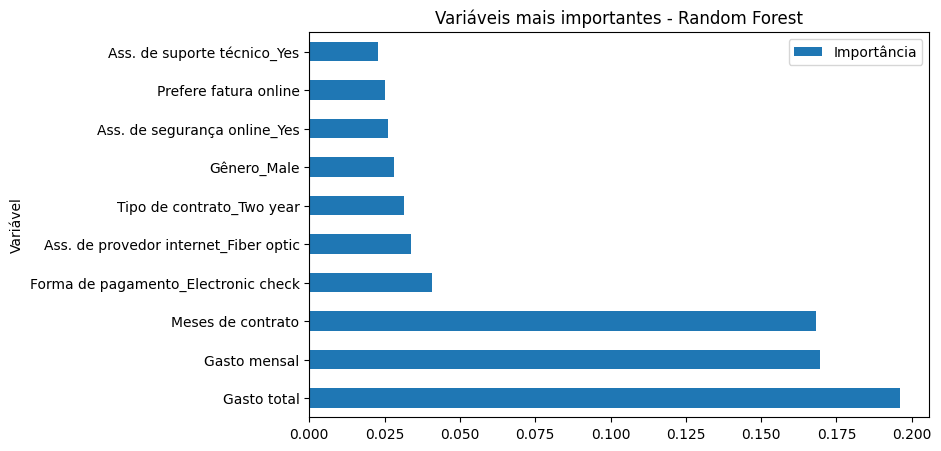

In [37]:
importancias.head(10).plot(
    x="Variável",
    y="Importância",
    kind="barh",
    figsize=(8,5)
)

plt.title("Variáveis mais importantes - Random Forest")
plt.show()

#📄Relatorio Final

# 📊 Relatório de Análise de Evasão de Clientes (Churn)

## 1. Introdução

A evasão de clientes (churn) é um problema relevante para empresas de telecomunicações, pois representa perda de receita e aumento dos custos de aquisição de novos clientes. Identificar antecipadamente quais clientes apresentam maior probabilidade de cancelar seus serviços permite que a empresa implemente estratégias de retenção mais eficientes.

Neste projeto, foi realizada uma análise exploratória e a construção de modelos de **Machine Learning** para prever a evasão de clientes com base em características demográficas, comportamento de consumo e serviços contratados.

Foram utilizados dois modelos de classificação:

- **Regressão Logística**
- **Random Forest**

O objetivo foi comparar o desempenho dos modelos e identificar os **principais fatores que influenciam a evasão de clientes**.

---

# 2. Extração e entendimento dos dados

Os dados foram carregados a partir do arquivo `telecomx_tratado.csv` utilizando a biblioteca **Pandas**.

O conjunto de dados possui:

- **7043 registros**
- **24 variáveis**

As variáveis incluem informações como:

- características do cliente (gênero, idade, dependentes)
- serviços contratados
- forma de pagamento
- tipo de contrato
- gastos mensais e totais

A variável alvo do problema é **Evasão**, indicando se o cliente cancelou ou permaneceu com o serviço.

A verificação de valores nulos indicou que **não existem dados ausentes**, o que facilita o processo de modelagem.

---

# 3. Preparação dos dados

Nesta etapa foram realizadas transformações para tornar os dados adequados para os modelos de Machine Learning.

## Remoção de colunas irrelevantes

Algumas colunas foram removidas por não contribuírem diretamente para o modelo ou por serem redundantes:

- `Cliente_id`
- `Faixa_gasto_mensal`
- `Faixa_tempo_contrato`
- `Gasto_diário`

A coluna **Cliente_id** é apenas um identificador e não possui valor preditivo.

As variáveis de **faixa** foram removidas porque já existem as versões numéricas originais.

---

## Separação entre variáveis explicativas e variável alvo

As variáveis foram separadas em:

- **X** → variáveis preditoras
- **y** → variável alvo (evasão)

---

## Encoding de variáveis categóricas

Como modelos de machine learning trabalham com dados numéricos, foi utilizado **One-Hot Encoding** com a função:

```python
pd.get_dummies()
```

Essa transformação converte variáveis categóricas em variáveis binárias.

Após o encoding, o conjunto de dados passou a possuir **30 variáveis preditoras**.

---

# 4. Análise exploratória

## Proporção de evasão

A análise da variável alvo mostrou a seguinte distribuição:

- **73,46% permaneceram**
- **26,53% cancelaram**

Isso indica um **leve desbalanceamento**, mas ainda aceitável para modelagem.

---

## Análise de correlação

Foi construída uma **matriz de correlação** para identificar relações entre as variáveis.

As variáveis com maior correlação positiva com evasão incluem:

- Internet **Fiber optic**
- **Electronic check** como forma de pagamento
- **Gasto mensal**
- Preferência por **fatura online**
- Clientes **idosos**

Já variáveis associadas à **menor probabilidade de evasão** incluem:

- **Maior tempo de contrato**
- **Contratos mais longos**
- Presença de **suporte técnico**
- Serviços de **segurança online**

Isso sugere que clientes com maior tempo de relacionamento e maior integração de serviços tendem a permanecer.

---

## Análise visual

Foram utilizados **boxplots** para analisar relações entre variáveis e evasão.

### Tempo de contrato

O gráfico mostra que clientes que cancelaram possuem, em média, **menos meses de contrato**.

Isso indica que clientes mais novos têm maior probabilidade de churn.

---

### Gasto total

Clientes que permanecem tendem a apresentar **maior gasto total acumulado**, refletindo maior tempo de permanência ou maior uso dos serviços.

---

# 5. Modelagem preditiva

## Separação entre treino e teste

Os dados foram divididos em:

- **80% treino**
- **20% teste**

Utilizando a função `train_test_split()` com **estratificação**, garantindo que a proporção de evasão fosse mantida nos dois conjuntos.

---

# 6. Modelos utilizados

## Modelo 1 — Regressão Logística

A regressão logística é um modelo linear amplamente utilizado em problemas de classificação binária.

Principais vantagens:

- fácil interpretação  
- baixo custo computacional  
- boa performance em problemas lineares  

---

## Modelo 2 — Random Forest

Random Forest é um algoritmo baseado em **conjunto de árvores de decisão**, capaz de capturar relações mais complexas entre variáveis.

Principais vantagens:

- captura interações entre variáveis  
- reduz risco de overfitting  
- maior capacidade de modelagem não linear  

---

# 7. Avaliação dos modelos

Os modelos foram avaliados utilizando as métricas:

- **Acurácia**
- **Precisão**
- **Recall**
- **F1-score**
- **Matriz de confusão**

---

## Resultados

| Modelo | Acurácia | Precisão | Recall | F1-score |
|------|------|------|------|------|
| Regressão Logística | 0.79 | 0.63 | 0.52 | 0.57 |
| Random Forest | 0.78 | 0.62 | 0.46 | 0.53 |

---

### Interpretação dos resultados

A **Regressão Logística apresentou desempenho ligeiramente superior**, especialmente nas métricas **recall** e **F1-score**.

Isso indica que o modelo conseguiu identificar melhor os clientes que realmente cancelaram o serviço.

---

## Matriz de confusão — Regressão Logística

Resultados:

- **921 clientes corretamente classificados como não evasão**
- **195 clientes corretamente classificados como evasão**
- **114 falsos positivos**
- **179 falsos negativos**

Os falsos negativos representam clientes que cancelaram mas não foram identificados pelo modelo.

---

# 8. Importância das variáveis

## Regressão Logística

As variáveis com maior impacto na previsão de evasão foram:

- **Internet Fiber optic**
- **Forma de pagamento Electronic check**
- **Preferência por fatura online**
- **Assinatura de múltiplas linhas**
- **Clientes idosos**

Essas variáveis apresentam maior peso nos coeficientes do modelo.

---

## Random Forest

As variáveis mais importantes foram:

- **Gasto total**
- **Gasto mensal**
- **Meses de contrato**
- **Forma de pagamento Electronic check**
- **Tipo de contrato**

Essas variáveis influenciam diretamente as decisões das árvores do modelo.

---

# 9. Principais fatores associados à evasão

### Maior risco de evasão

- Clientes com **internet Fiber optic**
- Pagamento via **Electronic check**
- **Clientes mais novos no serviço**
- **Gasto mensal elevado**
- Clientes que preferem **fatura online**

---

### Menor risco de evasão

- **Maior tempo de contrato**
- **Contratos de longo prazo**
- Clientes com **serviços adicionais**
- Clientes com **suporte técnico**

---

# 10. Estratégias de retenção

### Monitoramento de clientes novos

Clientes com poucos meses de contrato apresentam maior risco de evasão.  
A empresa pode implementar **programas de onboarding e acompanhamento inicial**.

### Incentivo a contratos mais longos

Contratos de **um ou dois anos** estão associados a menor churn.  
Oferecer descontos para contratos mais longos pode reduzir evasão.

### Revisão da experiência do cliente Fiber optic

Clientes com **Fiber optic** apresentaram maior risco de cancelamento.  
Isso pode indicar problemas de qualidade, preço elevado ou expectativas não atendidas.

### Incentivo a formas de pagamento automáticas

Clientes que utilizam **Electronic check** apresentaram maior evasão.  
Incentivar pagamentos automáticos pode reduzir cancelamentos.

---

# 11. Conclusão

Este projeto demonstrou como técnicas de análise de dados e machine learning podem ser utilizadas para prever a evasão de clientes em uma empresa de telecomunicações.

Os resultados indicam que fatores relacionados ao **tempo de contrato, tipo de serviço, forma de pagamento e padrões de consumo** exercem grande influência na decisão de cancelamento.

Entre os modelos testados, a **Regressão Logística apresentou melhor desempenho geral**, além de oferecer maior interpretabilidade.

A utilização desse tipo de modelo permite que empresas identifiquem clientes com maior risco de evasão e adotem estratégias preventivas, reduzindo perdas financeiras e melhorando o relacionamento com os clientes.